# Text-to-brain generation comparison

Compare MLP and CNN generation in their declared brain spaces on paired test examples. The published test split contains 3,066 PubMed, 79 Nilearn, and 202 NeuroVault examples. Because full PubMed generation evaluation is slow on a typical Mac, this notebook evaluates the first 200 PubMed examples and the complete Nilearn and NeuroVault splits. Set `DOMAIN_LIMITS["pubmed"] = None` to run the complete PubMed test split. CNN mixed-baseline heads are selected unless fine-tuned variants are requested explicitly.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from neurovlm import AtlasFreeCNNDataProvider, load_pipeline
from neurovlm.data.atlas_free_text import (
    AtlasFreeContrastiveCollator,
    AtlasFreeTextEmbeddingLookup,
    primary_positive_text,
)
from neurovlm.evaluation import (
    default_comparison_matrix, evaluate_text_to_brain_comparison,
)

DOMAINS = ("pubmed", "nilearn", "neurovault")
DOMAIN_LIMITS = {
    "pubmed": 200,       # runtime-conscious default; use None for all 3,066
    "nilearn": None,     # complete test split: 79
    "neurovault": None,  # complete test split: 202
}
INCLUDE_FINETUNED = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EVALUATION_SCOPE = "PubMed first 200; Nilearn and NeuroVault complete test splits"


In [2]:
results = []
for domain in DOMAINS:
    selections = default_comparison_matrix(
        "text_to_brain", domains=(domain,), include_finetuned=INCLUDE_FINETUNED
    )
    results.append(evaluate_text_to_brain_comparison(
        selections=selections,
        provider=AtlasFreeCNNDataProvider(domain=domain, limit=DOMAIN_LIMITS[domain]),
        device=DEVICE,
    ))
summary = pd.DataFrame(row for result in results for row in result.summary)
by_source = pd.DataFrame(row for result in results for row in result.by_source)
by_sample = pd.DataFrame(row for result in results for row in result.by_sample)
manifest = pd.DataFrame(row for result in results for row in result.manifest)
summary.sort_values(["evaluation_domain", "family", "variant"])

There are adapters available but none are activated for the forward pass.
There are adapters available but none are activated for the forward pass.
There are adapters available but none are activated for the forward pass.


,model_id,family,task,domain,variant,evaluation_domain,status,comparison_protocol,comparison_space,text_preprocessing,...,top10_overlap,top10_target_recall,top1_dice,top1_intersection_voxels,top1_overlap,top1_target_recall,top5_dice,top5_intersection_voxels,top5_overlap,top5_target_recall
5,cnn_text_to_brain_mixed_baseline_neurovault_ev...,cnn,text_to_brain,neurovault,mixed_baseline,neurovault,resolved,paired_atlas_free,native_atlas_free_volume,empty_string_centered_l2_unit_normalized,...,0.329312,0.329312,0.131349,80.910891,0.131349,0.131349,0.245337,755.148515,0.245337,0.245337
4,mlp_text_to_brain_eval_neurovault,mlp,text_to_brain,None,mse,neurovault,resolved,paired_atlas_free,mlp_masker_flatmap,specter2_adhoc_query_orthogonalized_then_l2,...,0.172033,0.172033,0.033753,9.653465,0.033753,0.033753,0.091425,130.554455,0.091425,0.091425
3,cnn_text_to_brain_mixed_baseline_nilearn_eval_...,cnn,text_to_brain,nilearn,mixed_baseline,nilearn,resolved,paired_atlas_free,native_atlas_free_volume,empty_string_centered_l2_unit_normalized,...,0.051943,0.051943,0.008240,5.075949,0.008240,0.008240,0.018161,55.898734,0.018161,0.018161
2,mlp_text_to_brain_eval_nilearn,mlp,text_to_brain,None,mse,nilearn,resolved,paired_atlas_free,mlp_masker_flatmap,specter2_adhoc_query_orthogonalized_then_l2,...,0.172467,0.172467,0.035894,10.265823,0.035894,0.035894,0.080842,115.443038,0.080842,0.080842
1,cnn_text_to_brain_mixed_baseline_pubmed_eval_p...,cnn,text_to_brain,pubmed,mixed_baseline,pubmed,resolved,paired_atlas_free,native_atlas_free_volume,empty_string_centered_l2_unit_normalized,...,0.303956,0.303956,0.114692,70.650000,0.114692,0.114692,0.240359,739.825000,0.240359,0.240359
0,mlp_text_to_brain_eval_pubmed,mlp,text_to_brain,None,mse,pubmed,resolved,paired_atlas_free,mlp_masker_flatmap,specter2_adhoc_query_orthogonalized_then_l2,...,0.188186,0.188186,0.023339,6.675000,0.023339,0.023339,0.091590,130.790000,0.091590,0.091590


`summary` contains spatial reconstruction metrics; `by_source` exposes the same metrics per corpus. This is a paired atlas-free comparison, but MLP and CNN outputs remain in different declared brain spaces. Compare trends and within-family domain changes; do not interpret their raw MSE values as voxel-identical measurements.

## Aggregate metrics

Lower is better for reconstruction MSE; higher is better for spatial correlation and top-5% Dice overlap.

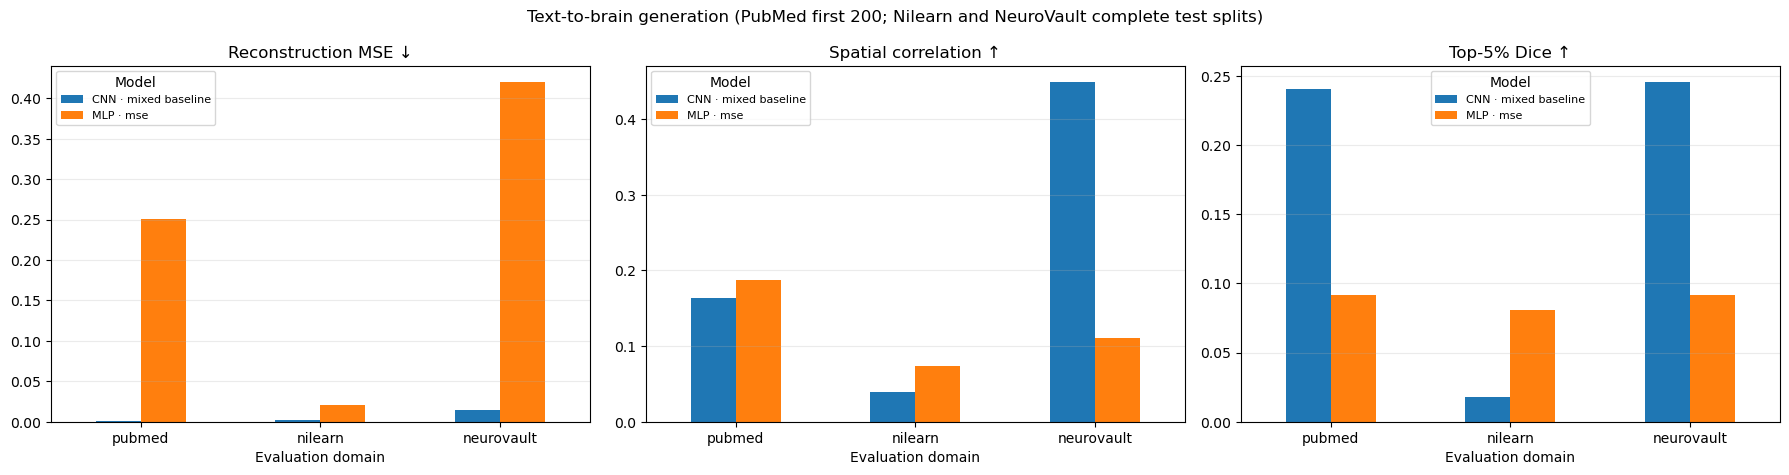

In [3]:
resolved = summary[(summary["status"] == "resolved") & (summary["n"] > 0)].copy()
if resolved.empty:
    raise RuntimeError("No models resolved. Inspect `manifest` for checkpoint errors.")
resolved["model"] = resolved.apply(
    lambda row: f'{row["family"].upper()} · {str(row["variant"]).replace("_", " ")}',
    axis=1,
)

metrics = (
    ("reconstruction_mse", "Reconstruction MSE ↓"),
    ("spatial_corr", "Spatial correlation ↑"),
    ("top5_dice", "Top-5% Dice ↑"),
)
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4.8))
for ax, (metric, title) in zip(axes, metrics):
    table = resolved.pivot(
        index="evaluation_domain", columns="model", values=metric
    ).reindex(DOMAINS)
    table.plot.bar(ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel("Evaluation domain")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Model", fontsize=8)
fig.suptitle(f"Text-to-brain generation ({EVALUATION_SCOPE})")
fig.tight_layout()
plt.show()

## Per-sample overlap distributions

The distributions expose variation hidden by the aggregate means.

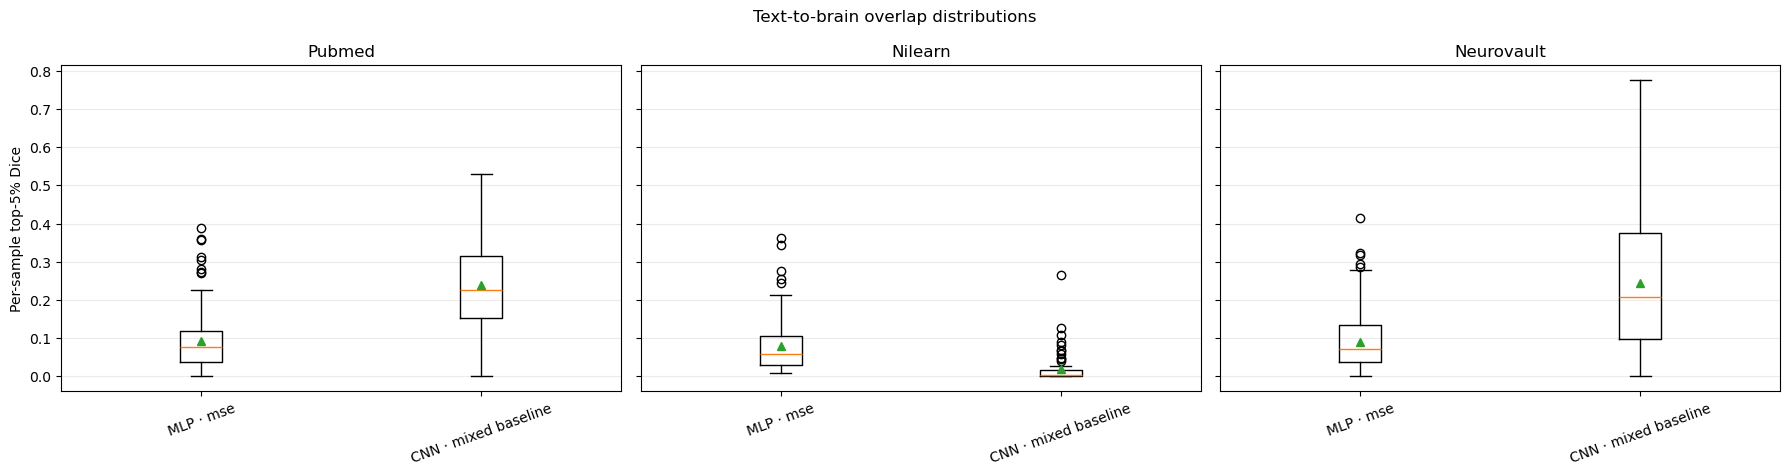

In [4]:
sample_rows = by_sample[by_sample["status"] == "resolved"].copy()
sample_rows["model"] = sample_rows.apply(
    lambda row: f'{row["family"].upper()} · {str(row["variant"]).replace("_", " ")}',
    axis=1,
)
models = list(dict.fromkeys(sample_rows["model"]))
fig, axes = plt.subplots(1, len(DOMAINS), figsize=(18, 4.8), sharey=True)
for ax, domain in zip(axes, DOMAINS):
    domain_rows = sample_rows[sample_rows["evaluation_domain"] == domain]
    values = [domain_rows.loc[domain_rows["model"] == model, "top5_dice"] for model in models]
    ax.boxplot(values, tick_labels=models, showmeans=True)
    ax.set_title(domain.title())
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Per-sample top-5% Dice")
fig.suptitle("Text-to-brain overlap distributions")
fig.tight_layout()
plt.show()

## Qualitative CNN generations

Generate three examples for each domain—nine generated brain maps total. All-zero targets are skipped, which avoids invisible Nilearn parcels lost during 4 mm resampling/cropping. The prompt table records the exact text paired with every original map. A dedicated cell shows those original maps; the generated maps then use the same anatomical plane and slice as their paired originals.

In [5]:
EXAMPLES_PER_DOMAIN = 3
PLANE_NAMES = ("sagittal", "coronal", "axial")
text_lookup = AtlasFreeTextEmbeddingLookup.published()
generated_examples = {}
paired_originals = {}
paired_slice_specs = {}
prompt_rows = []

def _first_nonempty_rows(domain, count=EXAMPLES_PER_DOMAIN):
    data = AtlasFreeCNNDataProvider(domain=domain).test
    rows = []
    skipped = 0
    for index in range(len(data)):
        row = data[index]
        if int(torch.count_nonzero(row["volume"])) == 0:
            skipped += 1
            continue
        rows.append(row)
        if len(rows) == count:
            break
    if len(rows) != count:
        raise RuntimeError(f"Only {len(rows)} non-empty {domain} examples were available")
    return rows, skipped

def _strongest_plane(volume):
    candidates = []
    for axis, plane_name in enumerate(PLANE_NAMES):
        reduce_dims = tuple(dim for dim in range(3) if dim != axis)
        scores = volume.abs().sum(dim=reduce_dims)
        slice_index = int(scores.argmax())
        candidates.append((float(scores[slice_index]), axis, slice_index, plane_name))
    _, axis, slice_index, plane_name = max(candidates)
    return volume.select(axis, slice_index), axis, slice_index, plane_name

def _robust_positive_max(values):
    positive = values[values > 0]
    if not len(positive):
        return max(float(values.abs().max()), 1e-8)
    return max(float(torch.quantile(positive.float(), 0.99)), 1e-8)

for domain in DOMAINS:
    visual_rows, skipped = _first_nonempty_rows(domain)
    visual_batch = AtlasFreeContrastiveCollator(
        text_lookup, (36, 45, 38)
    )(visual_rows)
    generator = load_pipeline(
        family="cnn", task="text_to_brain", domain=domain, device=DEVICE
    )
    generated = generator.generate(visual_batch["text_embedding"]).cpu()
    generated_examples[domain] = generated
    paired_originals[domain] = visual_batch["volume"].cpu()
    paired_slice_specs[domain] = [
        _strongest_plane(volume[0])[1:]
        for volume in paired_originals[domain]
    ]
    for index, row in enumerate(visual_rows):
        axis, slice_index, plane_name = paired_slice_specs[domain][index]
        prompt_rows.append({
            "domain": domain,
            "example": index + 1,
            "map_id": visual_batch["map_id"][index],
            "text_id": visual_batch["text_id"][index],
            "paired_text": primary_positive_text(row),
            "display_plane": plane_name,
            "slice_index": slice_index,
            "all_zero_maps_skipped_before_selection": skipped,
        })

prompt_table = pd.DataFrame(prompt_rows)
pd.set_option("display.max_colwidth", 120)
prompt_table

,domain,example,map_id,text_id,paired_text,display_plane,slice_index,all_zero_maps_skipped_before_selection
0,pubmed,1,pubmed_ale_34173239,pubmed_ale_34173239::pair_0,Enhanced insightfulness and neural activation induced by metaphorical solutions to appropriate mental distress probl...,sagittal,9,0
1,pubmed,2,pubmed_ale_23418930,pubmed_ale_23418930::pair_0,Neural correlates of behavioral variation in healthy adults' antisaccade performance. [SEP] During antisaccade perfo...,coronal,15,0
2,pubmed,3,pubmed_ale_22634217,pubmed_ale_22634217::pair_0,"Cerebral correlates of skin conductance responses in a cognitive task. [SEP] During cognitive tasks, physiological a...",sagittal,18,0
3,nilearn,1,nilearn_schaefer_2018_392_7networks_rh_default_pcunpcc_1,nilearn_schaefer_2018_392_7networks_rh_default_pcunpcc_1::pair_0,Right Default mode network parcel 1 [SEP] A large-scale functional network commonly associated with internally direc...,coronal,13,1
4,nilearn,2,nilearn_juelich_probabilistic_51_gm_visual_cortex_v3v,nilearn_juelich_probabilistic_51_gm_visual_cortex_v3v::pair_0,GM Visual cortex V3V [SEP] A functional network centered on occipital and extrastriate regions involved in visual pe...,axial,14,1
5,nilearn,3,nilearn_juelich_17_gm_inferior_parietal_lobule_pfop,nilearn_juelich_17_gm_inferior_parietal_lobule_pfop::pair_0,GM Inferior parietal lobule PFop [SEP] GM Inferior parietal lobule PFop is an anatomical brain region or atlas-defin...,axial,24,1
6,neurovault,1,neurovault_13877,neurovault_13877::pair_0,brain parcellation mcinet basc asym 33clusters,axial,15,0
7,neurovault,2,neurovault_13883,neurovault_13883::pair_0,brain parcellation mcinet basc sym 208clusters,axial,13,0
8,neurovault,3,neurovault_13894,neurovault_13894::pair_0,ttest ctrlvsmci seed #28 (superior medial frontal),axial,4,0


### Original brain maps paired with the text prompts

The grid order matches the prompt table: three original target maps for PubMed, three for Nilearn, and three for NeuroVault.

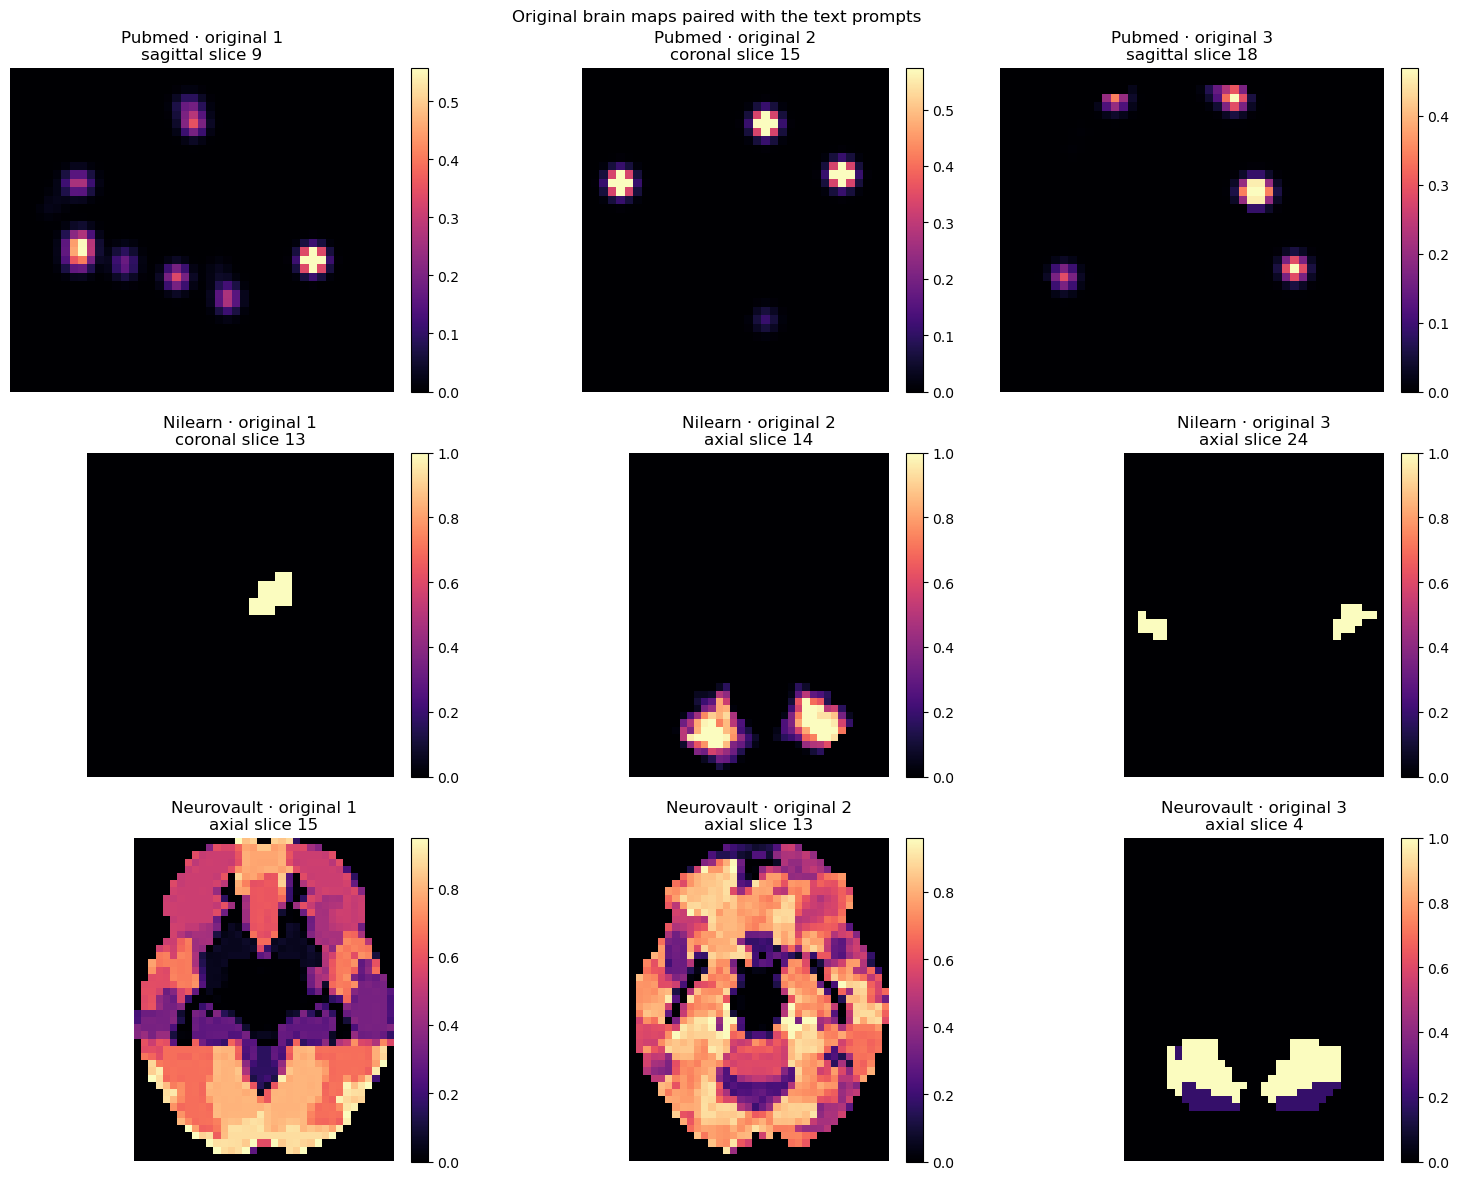

In [6]:
fig, axes = plt.subplots(
    len(DOMAINS), EXAMPLES_PER_DOMAIN, figsize=(15, 12)
)
for domain_index, domain in enumerate(DOMAINS):
    for example_index in range(EXAMPLES_PER_DOMAIN):
        volume = paired_originals[domain][example_index, 0]
        axis, slice_index, plane_name = paired_slice_specs[domain][example_index]
        plane = volume.select(axis, slice_index)
        ax = axes[domain_index, example_index]
        image = ax.imshow(
            plane.T,
            cmap="magma",
            origin="lower",
            vmin=0.0,
            vmax=_robust_positive_max(plane),
        )
        ax.set_title(
            f"{domain.title()} · original {example_index + 1}\n"
            f"{plane_name} slice {slice_index}"
        )
        ax.axis("off")
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Original brain maps paired with the text prompts")
fig.tight_layout()
plt.show()

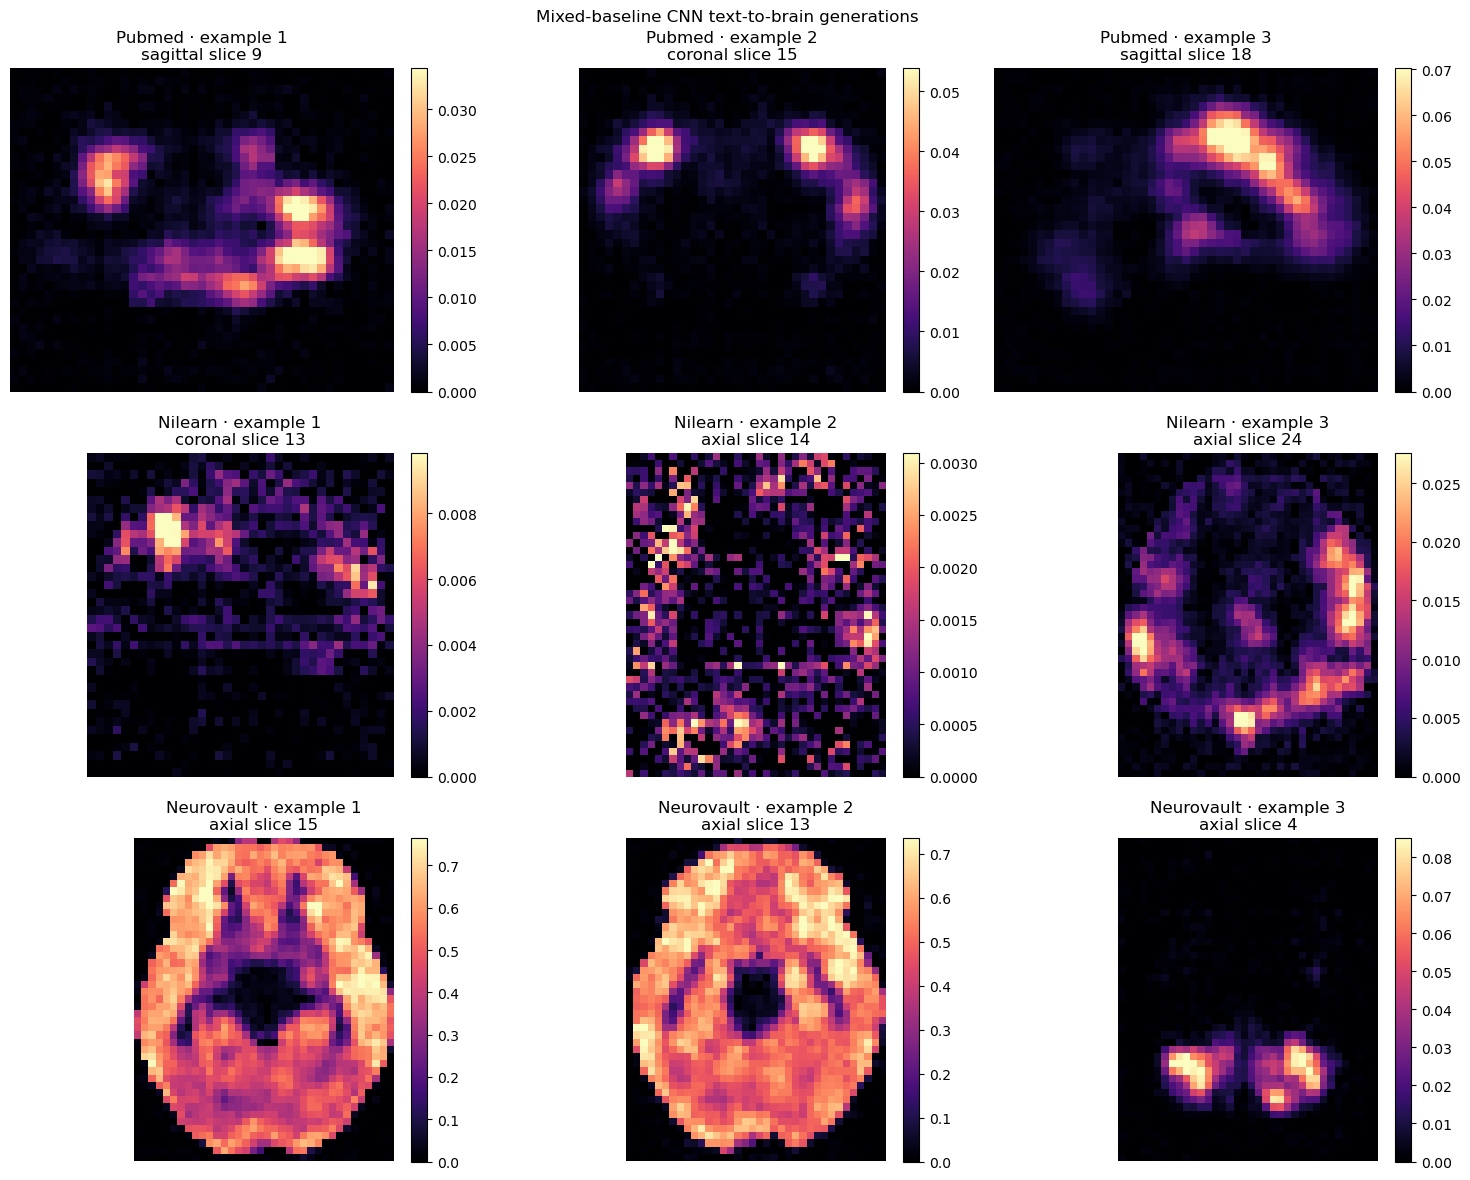

In [7]:
fig, axes = plt.subplots(
    len(DOMAINS), EXAMPLES_PER_DOMAIN, figsize=(15, 12)
)
for domain_index, domain in enumerate(DOMAINS):
    for example_index in range(EXAMPLES_PER_DOMAIN):
        volume = generated_examples[domain][example_index, 0]
        axis, slice_index, plane_name = paired_slice_specs[domain][example_index]
        plane = volume.select(axis, slice_index)
        ax = axes[domain_index, example_index]
        image = ax.imshow(
            plane.T,
            cmap="magma",
            origin="lower",
            vmin=0.0,
            vmax=_robust_positive_max(plane),
        )
        ax.set_title(
            f"{domain.title()} · example {example_index + 1}\n"
            f"{plane_name} slice {slice_index}"
        )
        ax.axis("off")
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Mixed-baseline CNN text-to-brain generations")
fig.tight_layout()
plt.show()

Use `ComparisonSelection(from_run=...)` when evaluating a local run rather than a released Hugging Face checkpoint. Mixed-baseline CNN heads remain the default; fine-tuned heads are included only when `INCLUDE_FINETUNED` is set explicitly.